# 2.2 cNMF analysis

Author: Xuezhu Sunny Wang

## Dataset 📊

- scRNA-seq data of plasma cells with known clonotype


## Steps overview 📒
- Run cNMF on the plasma cells
- Determine the number of components per the rule of highest stability and lowest error
- Plot the usage (activity) of each gene expression program in single plasma cell



In [1]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
from scipy.io import mmread
import scipy.sparse as sp
import matplotlib.pyplot as plt
from IPython.display import Image
import scanpy as sc
from cnmf import cNMF
    
np.random.seed(14)



In [2]:
#Filter IG the barcodes first

adata = sc.read_h5ad("counts_clean.h5ad") #used to be the plasma cell sample
import re

# Find genes starting with IGK, IGH, or IGL
ig_genes = [gene for gene in adata.var_names if re.match(r"^(IGK|IGH|IGL)", gene)]

# Now filter out these genes
adata = adata[:, ~adata.var_names.isin(ig_genes)].copy()

# List of cells to remove
cells_to_remove = ['ALl9preplasma_GTCACGGAGTGCGTGA-1', 'ALl5preplasma_GCATGTATCACAGTAC-1', 'N1plasma_ACGAGGACATCAGTAC-1', 'N1plasma_GCTCTGTAGAAACGAG-1','ALl6preplasma_TAGACCACAGTATGCT-1', 'ALl3preplasma_TAAACCGGTACTCTCC-1', 'N2plasma_CAGGTGCGTCTTGATG-1', 'ALk6plasma_ATTACTCAGCCAGTTT-1']

# Keep only the cells not in that list
adata = adata[~adata.obs_names.isin(cells_to_remove)].copy()

count_adat_fn = 'counts_clean_withoutIG.h5ad'
sc.write(count_adat_fn, adata)


In [3]:
numiter=20 # Number of NMF replicates. Set this to a larger value ~200 for real data. We set this to a relatively low value here for illustration at a faster speed
numhvgenes=2000 ## Number of over-dispersed genes to use for running the actual factorizations

## Results will be saved to [output_directory]/[run_name] which in this example is example_PBMC/cNMF/pbmc_cNMF
output_directory = './cNMF_withoutIG_k=13'
if not os.path.exists(output_directory):
    os.mkdir(output_directory)
run_name = 'plasma_cNMF_3_withoutIG_k=13'

## Specify the Ks to use as a space separated list in this case "5 6 7 8 9 10"
K = ' '.join([str(i) for i in range(5,11)])

## To speed this up, you can run it for only K=7-8 with the option below
#K = ' '.join([str(i) for i in range(7,9)])


seed = 14 ## Specify a seed pseudorandom number generation for reproducibility

## Path to the filtered counts dataset we output previously
countfn = './counts_clean_withoutIG.h5ad'


In [4]:
## Initialize the cnmf object that will be used to run analyses
cnmf_obj = cNMF(output_dir=output_directory, name=run_name)


In [5]:
## Prepare the data, I.e. subset to 2000 high-variance genes, and variance normalize
cnmf_obj.prepare(counts_fn=countfn, components=np.arange(9,15), n_iter=20, seed=14, num_highvar_genes=2000)

/lab-share/home/Public/Sunny/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [6]:
## Specify that the jobs are being distributed over a single worker (total_workers=1) and then launch that worker
cnmf_obj.factorize(worker_i=0, total_workers=1)

[Worker 0]. Starting task 0.
[Worker 0]. Starting task 1.
[Worker 0]. Starting task 2.
[Worker 0]. Starting task 3.
[Worker 0]. Starting task 4.
[Worker 0]. Starting task 5.
[Worker 0]. Starting task 6.
[Worker 0]. Starting task 7.
[Worker 0]. Starting task 8.
[Worker 0]. Starting task 9.
[Worker 0]. Starting task 10.
[Worker 0]. Starting task 11.
[Worker 0]. Starting task 12.
[Worker 0]. Starting task 13.
[Worker 0]. Starting task 14.
[Worker 0]. Starting task 15.
[Worker 0]. Starting task 16.
[Worker 0]. Starting task 17.
[Worker 0]. Starting task 18.
[Worker 0]. Starting task 19.
[Worker 0]. Starting task 20.
[Worker 0]. Starting task 21.
[Worker 0]. Starting task 22.
[Worker 0]. Starting task 23.
[Worker 0]. Starting task 24.
[Worker 0]. Starting task 25.
[Worker 0]. Starting task 26.
[Worker 0]. Starting task 27.
[Worker 0]. Starting task 28.
[Worker 0]. Starting task 29.
[Worker 0]. Starting task 30.
[Worker 0]. Starting task 31.
[Worker 0]. Starting task 32.
[Worker 0]. Starting

In [7]:
cnmf_obj.combine()

Combining factorizations for k=9.
Combining factorizations for k=10.
Combining factorizations for k=11.
Combining factorizations for k=12.
Combining factorizations for k=13.
Combining factorizations for k=14.


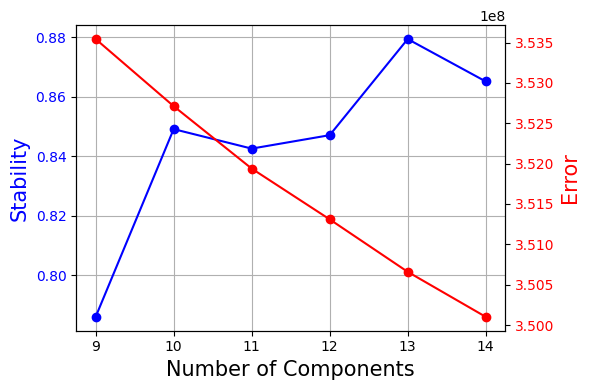

In [8]:
cnmf_obj.k_selection_plot(close_fig=False)

In [9]:
print('This saves the corresponding figure to the following file: %s' % cnmf_obj.paths['k_selection_plot'])

This saves the corresponding figure to the following file: ./cNMF_withoutIG_k=11/plasma_cNMF_3_withoutIG_k=11/plasma_cNMF_3_withoutIG_k=11.k_selection.png


In [10]:
kselect_plot_cmd = 'cnmf k_selection_plot --output-dir ./cNMF_withoutIG_k=13 --name cNMF_withoutIG_k=13'
print('K selection plot command: %s' % kselect_plot_cmd)
#!{kselect_plot_cmd}

K selection plot command: cnmf k_selection_plot --output-dir example_PBMC_withoutIG_k=11/cNMF --name pbmc_cNMF_withoutIG_k=11


In [11]:
selected_K = 13
density_threshold = 2.00

In [12]:
import pickle

with open("cnmf_obj_withoutIG_k=13.pkl", "wb") as f:
    pickle.dump(cnmf_obj, f)

/lab-share/home/Public/Sunny/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/cnmf/cnmf.py:895: RuntimeWarning: invalid value encountered in divide
  norm_tpm = (np.array(tpm.X.todense()) - tpm_stats['__mean'].values) / tpm_stats['__std'].values
/lab-share/home/Public/Sunny/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


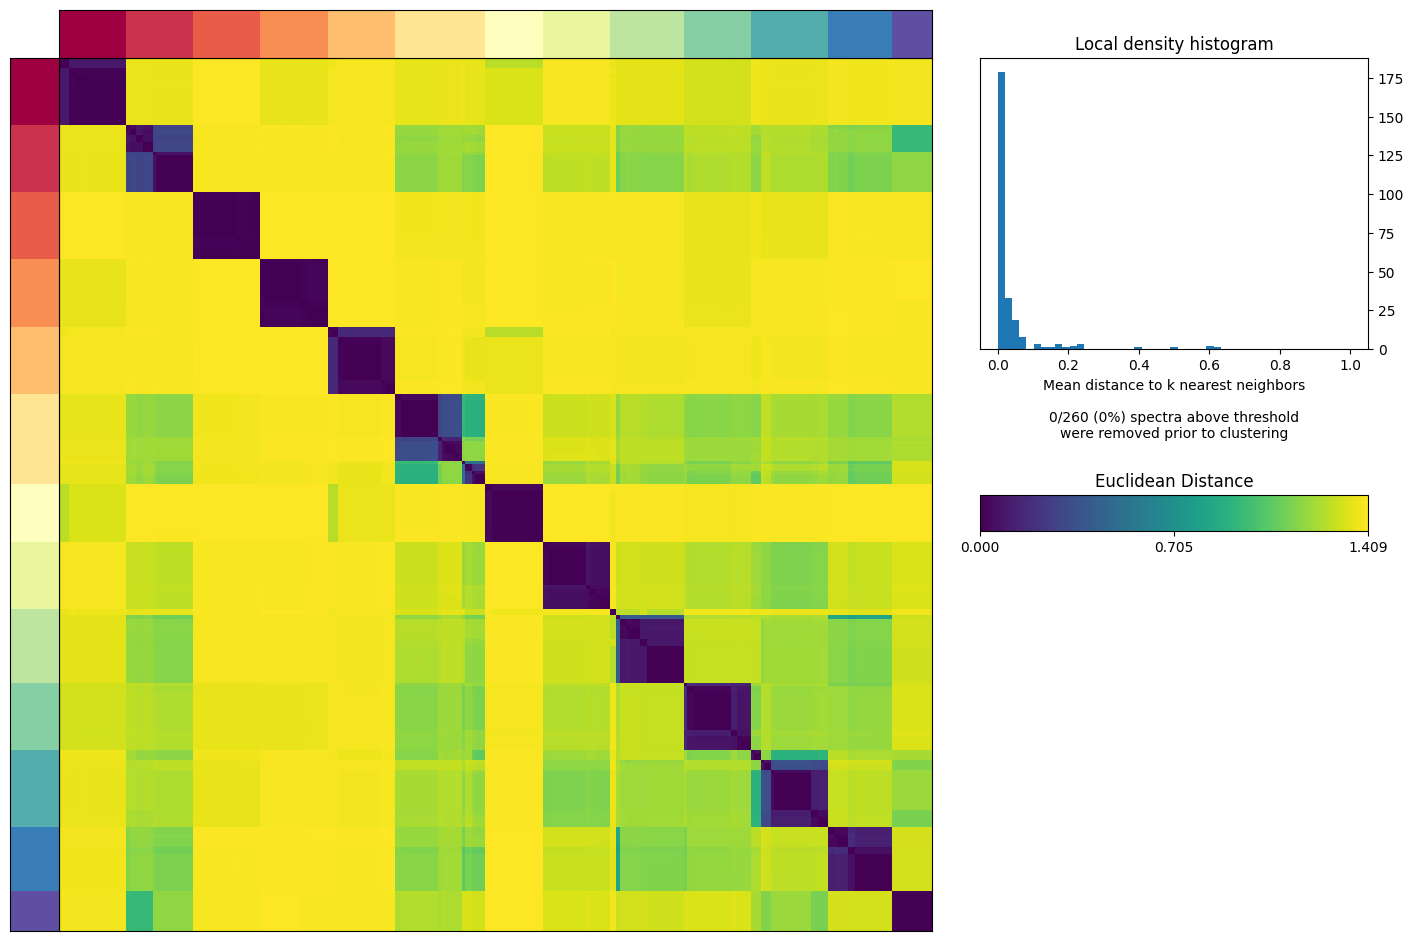

In [13]:
cnmf_obj.consensus(k=selected_K, density_threshold=density_threshold, show_clustering=True, close_clustergram_fig=False)

In [14]:
density_threshold = 0.20

/lab-share/home/Public/Sunny/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/cnmf/cnmf.py:895: RuntimeWarning: invalid value encountered in divide
  norm_tpm = (np.array(tpm.X.todense()) - tpm_stats['__mean'].values) / tpm_stats['__std'].values
/lab-share/home/Public/Sunny/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


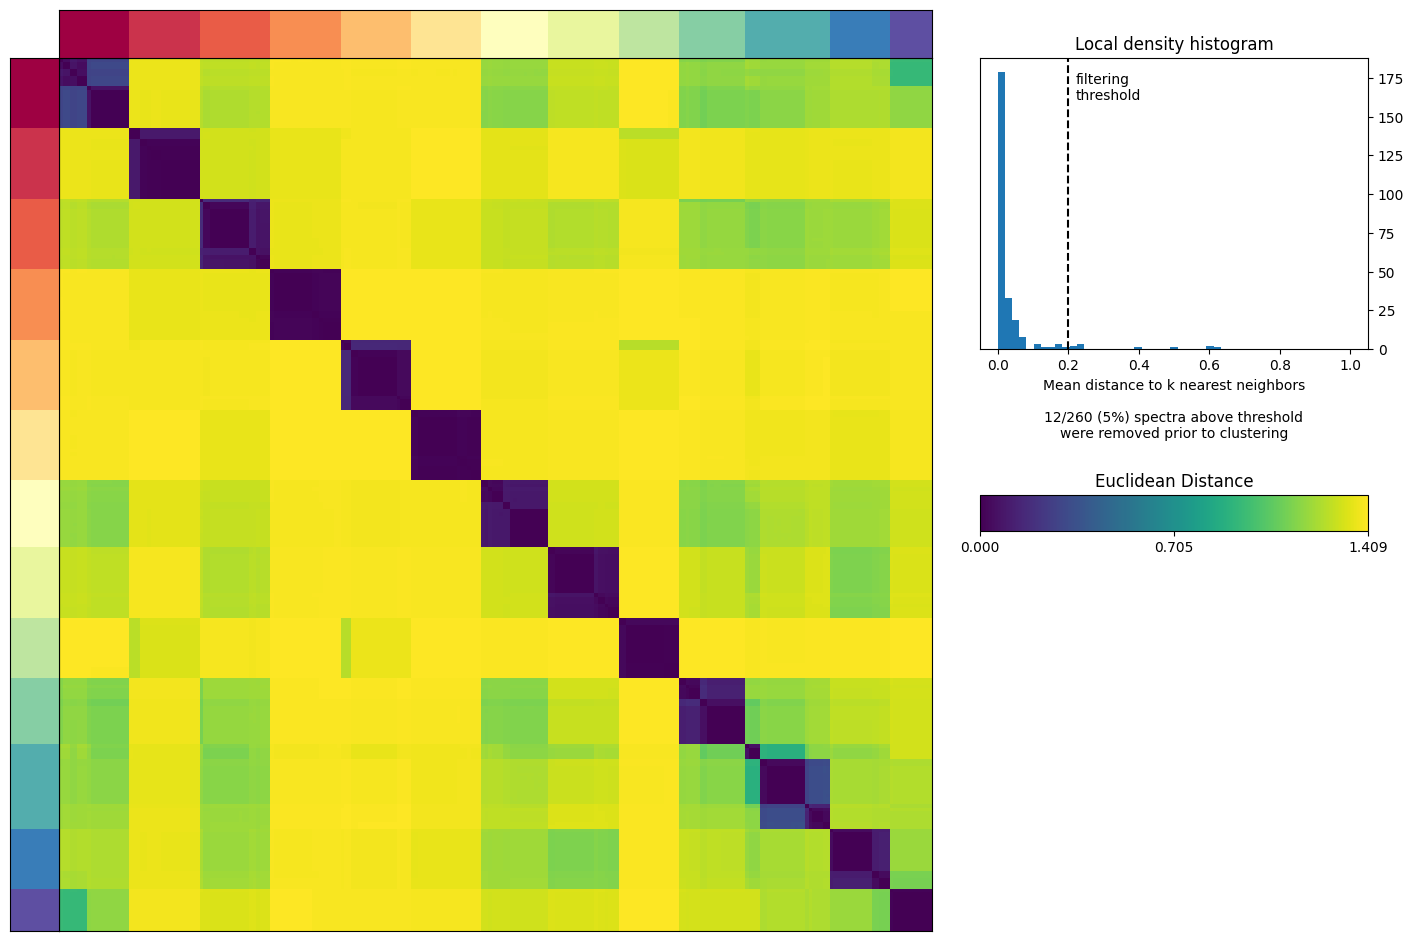

In [15]:
cnmf_obj.consensus(k=selected_K, density_threshold=density_threshold, show_clustering=True, close_clustergram_fig=False)

In [16]:
adata = sc.read(countfn)

In [17]:
## Obtain high variance genes that were used for cNMF as these were saved to a text file
hvgs = open('./cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.overdispersed_genes.txt').read().split('\n')

In [18]:
sc.pp.normalize_per_cell(adata, counts_per_cell_after=10**4) ## TPT normalization

/lab-share/home/Public/Sunny/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


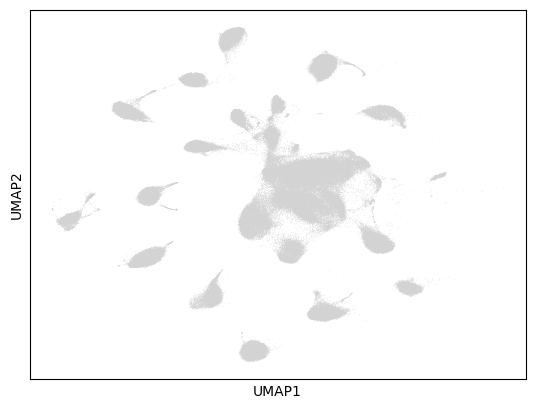

In [19]:
sc.pl.umap(adata)

In [20]:


usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(K=selected_K, density_threshold=density_threshold)
usage_norm.columns = ['Usage_%d' % i for i in usage_norm.columns]



In [21]:


usage_file = cnmf_obj.paths['consensus_usages__txt'] % (selected_K, '0_1')
print(usage_file)



./cNMF_withoutIG_k=11/plasma_cNMF_3_withoutIG_k=11/plasma_cNMF_3_withoutIG_k=11.usages.k_13.dt_0_1.consensus.txt


In [22]:


gene_scores_file = cnmf_obj.paths['gene_spectra_score__txt'] % (selected_K, '0_1')
print(gene_scores_file)



./cNMF_withoutIG_k=11/plasma_cNMF_3_withoutIG_k=11/plasma_cNMF_3_withoutIG_k=11.gene_spectra_score.k_13.dt_0_1.txt


In [23]:


gene_tpm_file = cnmf_obj.paths['gene_spectra_tpm__txt'] % (selected_K, '0_1')
print(gene_tpm_file)



./cNMF_withoutIG_k=11/plasma_cNMF_3_withoutIG_k=11/plasma_cNMF_3_withoutIG_k=11.gene_spectra_tpm.k_13.dt_0_1.txt


In [24]:
adata.obs = pd.merge(left=adata.obs, right=usage_norm, how='left', left_index=True, right_index=True)

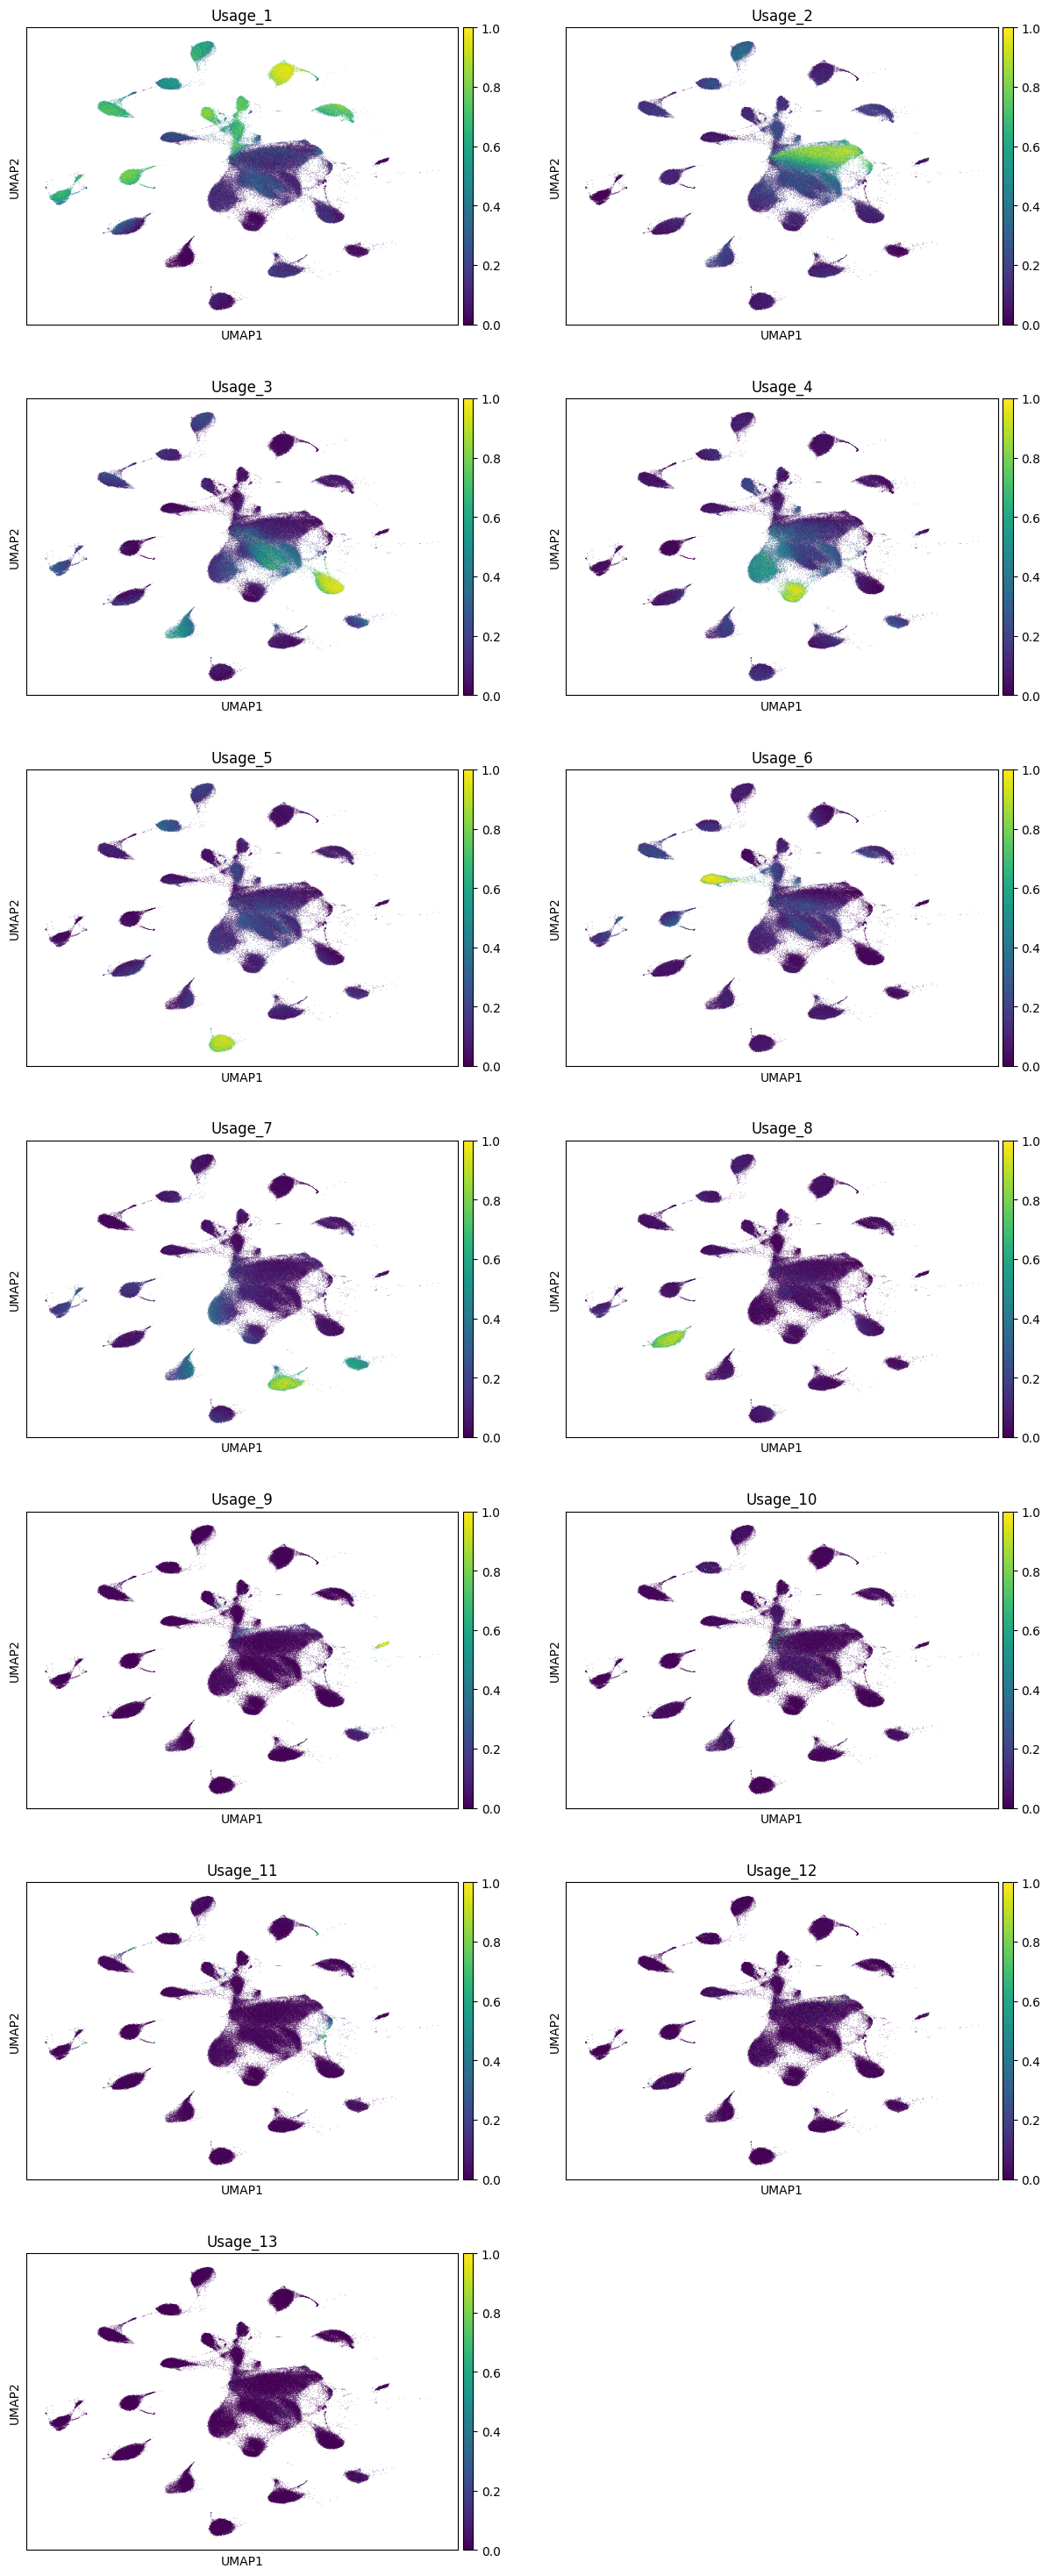

In [25]:


sc.pl.umap(adata, color=usage_norm.columns,ncols=2, vmin=0, vmax=1)



In [26]:
topgenes.head()

,1,2,3,4,5,6,7,8,9,10,11,12,13
0,DHRS9,CD19,MS4A1,CFHR1,AC233755.1,PPP1R14A,WFDC2,AC233755.2,S100A9,NRGN,RRM2,C1QB,TRBC1
1,NEB,RNASE6,CCL3,AC246787.2,LY6K,CST6,G0S2,TMEM176B,LYZ,TUBB1,MKI67,C1QC,GNLY
2,PTP4A3,CD27,FGF7,FAM30A,GPR15,SPON2,CRIP1,NSD2,FCN1,PPBP,TYMS,APOE,FGFBP2
3,AL353753.1,HLA-DPA1,LAPTM5,CTSW,SLC2A5,CGREF1,LAMP5,TMEM176A,VCAN,GP9,STMN1,C1QA,NKG7
4,NUDT12,HLA-DQB1,CPVL,SLC22A17,DDIT4,TMEM119,MT1E,AZGP1,S100A8,MPIG6B,UBE2C,APOC1,KLRB1


In [28]:
usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(K=13, density_threshold=.2)
usage_norm.columns = ['Usage_%d' % i for i in usage_norm.columns]
usage_norm.head()

,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7,Usage_8,Usage_9,Usage_10,Usage_11,Usage_12,Usage_13
ALl14plasma_AAACCTGAGAGCTGCA-1,0.002053,0.401754,0.276476,0.171477,0.000000,0.000000,0.000000,0.037491,0.054811,0.000000,0.023788,0.028762,0.003388
ALl14plasma_AAACCTGAGAGTCGGT-1,0.000000,0.306133,0.377046,0.249656,0.037767,0.022180,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007218
ALl14plasma_AAACCTGAGATAGCAT-1,0.043966,0.202475,0.406332,0.209408,0.000000,0.088113,0.049137,0.000000,0.000000,0.000000,0.000000,0.000000,0.000568
ALl14plasma_AAACCTGAGCTTTGGT-1,0.192226,0.331219,0.000000,0.115991,0.083257,0.127800,0.128071,0.016249,0.000000,0.002862,0.000000,0.000000,0.002324
ALl14plasma_AAACCTGAGGGAACGG-1,0.146918,0.162768,0.234673,0.244345,0.091635,0.066566,0.044478,0.000000,0.000000,0.005439,0.000000,0.000000,0.003179


In [29]:
topgenes

,1,2,3,4,5,6,7,8,9,10,11,12,13
0,DHRS9,CD19,MS4A1,CFHR1,AC233755.1,PPP1R14A,WFDC2,AC233755.2,S100A9,NRGN,RRM2,C1QB,TRBC1
1,NEB,RNASE6,CCL3,AC246787.2,LY6K,CST6,G0S2,TMEM176B,LYZ,TUBB1,MKI67,C1QC,GNLY
2,PTP4A3,CD27,FGF7,FAM30A,GPR15,SPON2,CRIP1,NSD2,FCN1,PPBP,TYMS,APOE,FGFBP2
3,AL353753.1,HLA-DPA1,LAPTM5,CTSW,SLC2A5,CGREF1,LAMP5,TMEM176A,VCAN,GP9,STMN1,C1QA,NKG7
4,NUDT12,HLA-DQB1,CPVL,SLC22A17,DDIT4,TMEM119,MT1E,AZGP1,S100A8,MPIG6B,UBE2C,APOC1,KLRB1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,CCN2,CHCHD2,RENBP,RPN1,NRCAM,PIK3R5,MGST2,LRMDA,SCIMP,SH3BGRL3,TUBB,PKD2L1,JAKMIP1
96,IFI30,TXNDC15,DUSP2,C7orf50,MIR22HG,SLCO4A1,RHOC,EYA4,GAPT,JAKMIP1,PRC1,IGFBP4,EMILIN2
97,RACK1,KCNMA1,IER2,AC078883.1,TUBA1C,KIF3C,SGK1,PPIB,APOBR,BEND2,ATAD2,RAB32,GIMAP4
98,HIST1H2BC,IFI35,AL118516.1,NUGGC,ACTG1,ELFN1-AS1,TBXAS1,UACA,MARCH1,KLRB1,FANCI,GSDMA,PLXDC2


In [30]:
topgenes.to_csv("plasma_cnmf_3_topgenes_withoutIG_k=13.csv", index=True)
usage_norm.to_csv("plasma_cnmf_3_usage_norm_withoutIG_k=13.csv", index=True)